<a href="https://colab.research.google.com/github/tokiror/maple-scholars-2026/blob/main/%20kongwa_raw_grace_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Raw GRACE Water Storage Analysis — Kongwa, Tanzania

**Project:** Natural water reservoirs and drought characterization in Kongwa District, Tanzania
**Author:** Timothy Masaba Okiror
**Program:** Maple Scholars 2026
**Last updated:** 09 June 2026

## Purpose
This notebook analyzes raw GRACE satellite total water storage anomaly (TWSA)
data over Kongwa District, Tanzania. To partly compensate for GRACE's coarse
resolution, Kongwa is split into two sub-regions (West and East) and analyzed
separately, then compared.

## Data Source
- **Product:** NASA JPL GRACE/GRACE-FO MASCON (extracted via Google Earth Engine)
- **Variable:** water storage anomaly (`water_storage_cm`)
- **Coverage:** 2008–2022, monthly
- **Units:** centimeters (cm) equivalent water height
- **Baseline:** anomalies relative to the 2004–2010 mean
- **Native resolution:** ~3° true (provided on a 0.5° grid, ~55 km)

## What this notebook does
1. Loads West and East Kongwa GRACE time series (exported from GEE as CSVs)
2. Converts date columns and sorts chronologically
3. Drops months with missing data
4. Plots West and East Kongwa water storage individually and together for comparison

## Key observation
Both sub-regions show a strong rise in water storage beginning ~2019–2020,
following relatively stable/low conditions in earlier years.

## Related work
- Companion notebook (`kongwa_grace_seda_analysis.ipynb`) uses a deep-learning
  downscaled GRACE product (Gou & Soja 2024) for higher-resolution comparison.
- Companion GEE script (`kongwa_twsa_map.js`) visualizes the downscaled data on a map.




In [ ]:

import pandas as pd


west = pd.read_csv('Kongwa_West_TimeSeries_2008_2022.csv')
east = pd.read_csv('Kongwa_East_TimeSeries_2008_2022.csv')

# Look at what loaded
print("West data shape:", west.shape)
print(west.head())
print("\nEast data shape:", east.shape)
print(east.head())

West data shape: (138, 4)
        system:index        date  water_storage_cm  \
0  20080131_20080228  2008-01-31          6.515206   
1  20080229_20080330  2008-02-29         10.972550   
2  20080331_20080429  2008-03-31         13.523895   
3  20080430_20080530  2008-04-30         14.467447   
4  20080531_20080629  2008-05-31         11.402492   

                                     .geo  
0  {"type":"MultiPoint","coordinates":[]}  
1  {"type":"MultiPoint","coordinates":[]}  
2  {"type":"MultiPoint","coordinates":[]}  
3  {"type":"MultiPoint","coordinates":[]}  
4  {"type":"MultiPoint","coordinates":[]}  

East data shape: (138, 4)
        system:index        date  water_storage_cm  \
0  20080131_20080228  2008-01-31          3.316809   
1  20080229_20080330  2008-02-29          6.338764   
2  20080331_20080429  2008-03-31          7.419451   
3  20080430_20080530  2008-04-30          7.675208   
4  20080531_20080629  2008-05-31          6.390378   

                                 

In [ ]:


# Convert the date column from text to actual dates
west['date'] = pd.to_datetime(west['date'])
east['date'] = pd.to_datetime(east['date'])

# Sort by date (just in case they are out of order)
west = west.sort_values('date')
east = east.sort_values('date')

# Drop any rows where water storage is missing (null months)
west = west.dropna(subset=['water_storage_cm'])
east = east.dropna(subset=['water_storage_cm'])

print("West months with data:", len(west))
print("East months with data:", len(east))

West months with data: 138
East months with data: 138


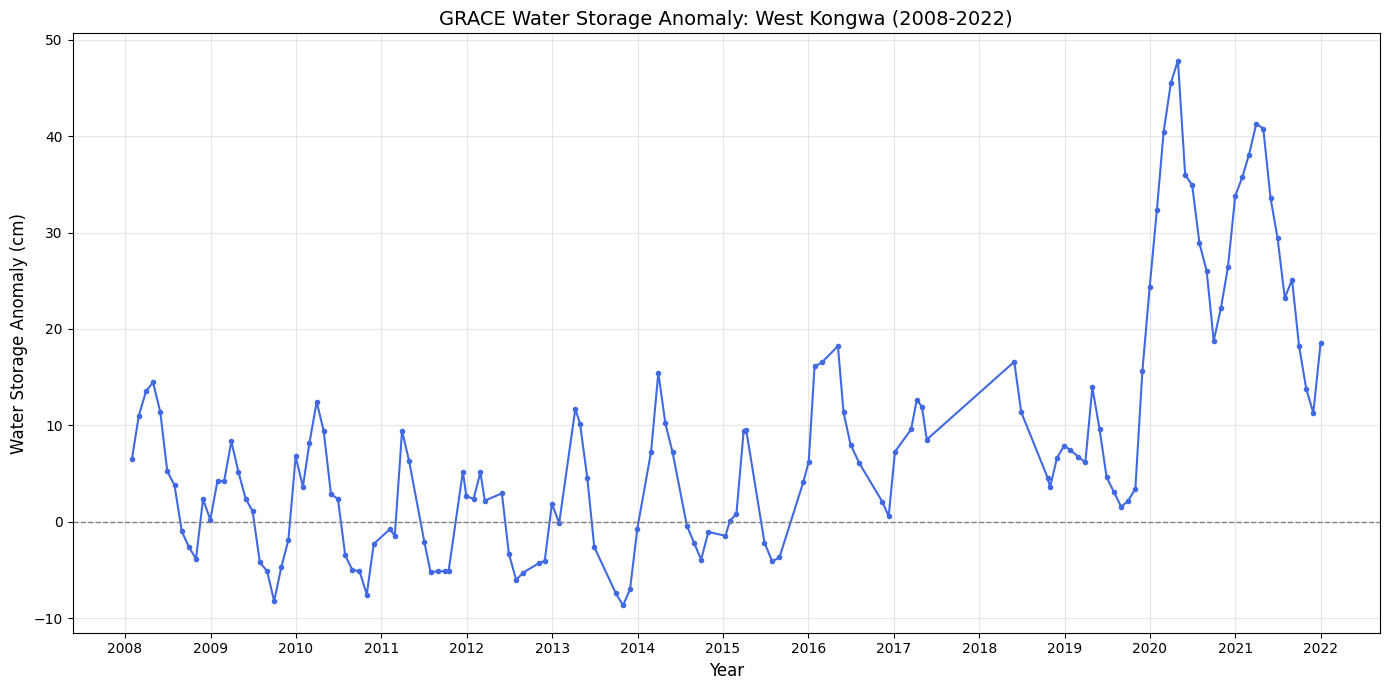

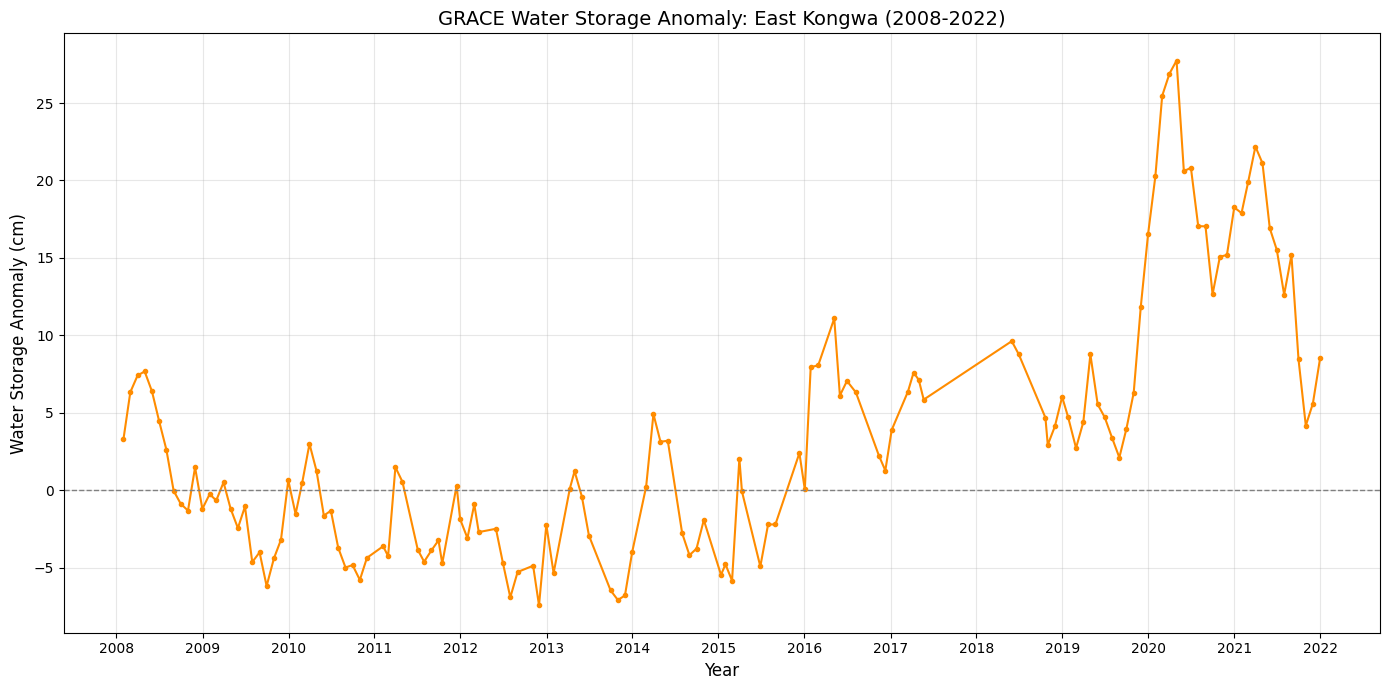

In [ ]:

import matplotlib.dates as mdates

west['date'] = pd.to_datetime(west['date'])
east['date'] = pd.to_datetime(east['date'])

plt.figure(figsize=(14, 7))

plt.plot(west['date'], west['water_storage_cm'],
         color='royalblue', linewidth=1.5,
         marker='o', markersize=3)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title('GRACE Water Storage Anomaly: West Kongwa (2008-2022)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Water Storage Anomaly (cm)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))

plt.plot(east['date'], east['water_storage_cm'],
         color='darkorange', linewidth=1.5,
         marker='o', markersize=3)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title('GRACE Water Storage Anomaly: East Kongwa (2008-2022)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Water Storage Anomaly (cm)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

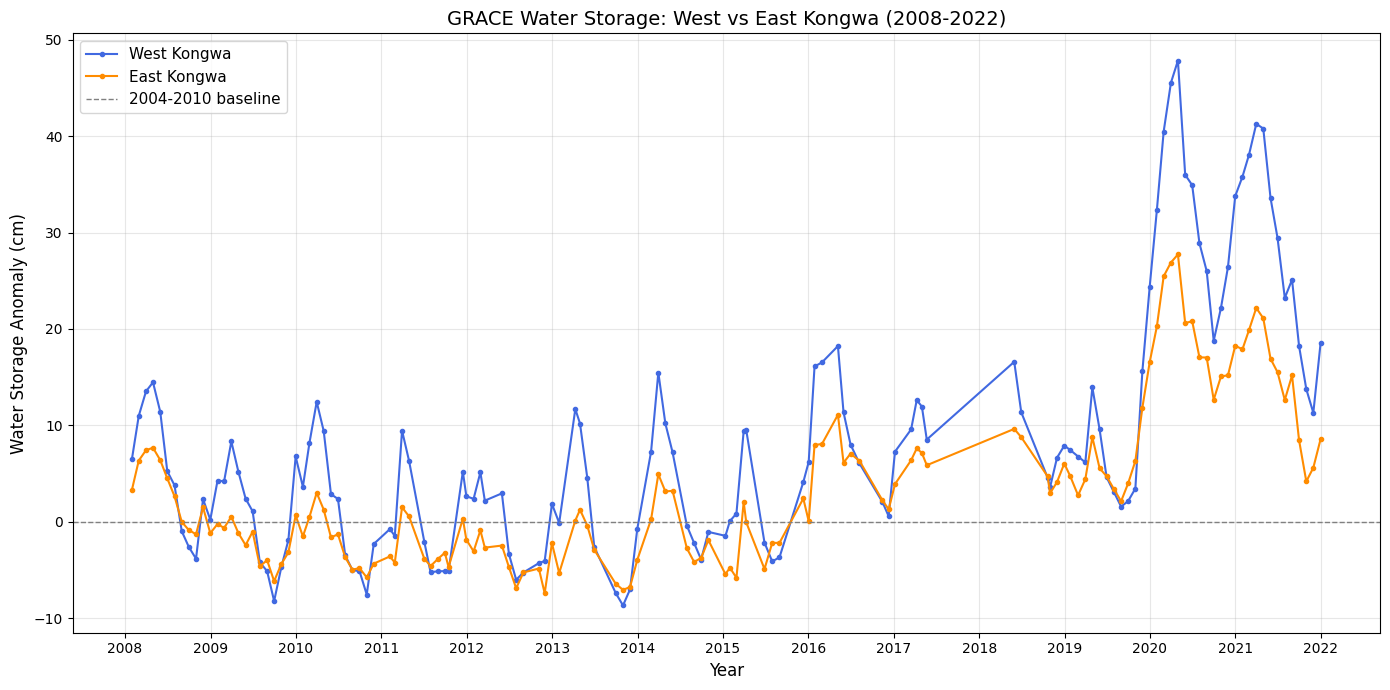

In [ ]:

west['date'] = pd.to_datetime(west['date'])
east['date'] = pd.to_datetime(east['date'])

plt.figure(figsize=(14, 7))

plt.plot(west['date'], west['water_storage_cm'],
         color='royalblue', linewidth=1.5,
         marker='o', markersize=3,
         label='West Kongwa')

plt.plot(east['date'], east['water_storage_cm'],
         color='darkorange', linewidth=1.5,
         marker='o', markersize=3,
         label='East Kongwa')

plt.axhline(y=0, color='gray', linestyle='--',
            linewidth=1, label='2004-2010 baseline')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=0)

plt.title('GRACE Water Storage: West vs East Kongwa (2008-2022)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Water Storage Anomaly (cm)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()